# Evaluation
## Introduction

This file is introduced for unifying evaluate the result from each pipeline, as the result has been required for recorded in standard pattern. In each record of the result from each pipeline, it will contain 3 main parts for evaluation:
1. gold_label
2. predicted_label
3. reason

The predicted labels will be introduced for evaluating whether matches the gold labels. Based on the result, the confusion matrix could be generated and then compute the matrics such as Recall, Presion and Macro-F1 for quantifying the performance. Here is an example of record from NoRAG result over training set.

```json
  {
    "claim_id": "claim_003055",
    "claim": "Kenyans working at Mara North private wildlife park have been made to carry white tourists in sedan chairs depicting modern 'slavery'",
    "gold_label": "Refuted",
    "predicted_label": "Refuted",
    "reason": "There is no widely reported or verified evidence suggesting that Kenyans are being forced to carry white tourists in sedan chairs at the Mara North private wildlife park. Such practices, if true, would likely be a significant human rights issue and have garnered attention from media and human rights organizations.",
    "model_name": "qwen2.5:7b",
    "error": null
  }
```

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    
)

In [2]:
RESULT_PATH = Path(r"chunking_test\report\embedding\chunks_200_overlap_50_report.json")

LABELS = [
    "Supported",
    "Refuted",
    "Not Enough Evidence",
    "Conflicting Evidence/Cherrypicking",
]

LABEL_TO_ID = {label: i for i, label in enumerate(LABELS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

In [3]:
def load_prediction_json(path: Path) -> pd.DataFrame:
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError("Prediction file should be a JSON list of records.")
    df = pd.DataFrame(data)
    return df


df_raw = load_prediction_json(RESULT_PATH)
print(f"Loaded records: {len(df_raw):,}")
df_raw.head()

Loaded records: 200


,claim_id,claim,gold_label,predicted_label,reason,retriever,chunking_method,embedding_model,model_name,temperature,retrieved_evidence,raw_response,error
0,1,Donald Trump delivered the largest tax cuts in...,Refuted,Refuted,The evidence consistently shows that President...,Dense,word_overlap,BAAI/bge-small-en-v1.5,qwen2.5:7b,0.0,"[{'rank': 1, 'docid': '1_2_0', 'score': 0.8551...","{\n ""predicted_label"": ""Refuted"",\n ""reason""...",None
1,6,35% of revenue goes to states. (In Nigeria),Refuted,Not Enough Evidence,The provided evidence does not specifically ad...,Dense,word_overlap,BAAI/bge-small-en-v1.5,qwen2.5:7b,0.0,"[{'rank': 1, 'docid': '6_718_217', 'score': 0....","{\n ""predicted_label"": ""Not Enough Evidence"",...",None
2,21,There is a ‘global average’ for the number of ...,Not Enough Evidence,Supported,Evidence 4 directly states that there are 278 ...,Dense,word_overlap,BAAI/bge-small-en-v1.5,qwen2.5:7b,0.0,"[{'rank': 1, 'docid': '21_96_522', 'score': 0....","{\n ""predicted_label"": ""Supported"",\n ""reaso...",None
3,50,South Africans drink more per person than anyw...,Refuted,Supported,The evidence consistently indicates that South...,Dense,word_overlap,BAAI/bge-small-en-v1.5,qwen2.5:7b,0.0,"[{'rank': 1, 'docid': '50_186_0', 'score': 0.8...","{\n ""predicted_label"": ""Supported"",\n ""r...",None
4,60,Democrats recited the US Pledge of Allegiance ...,Refuted,Supported,Evidence 1 directly supports the claim by repo...,Dense,word_overlap,BAAI/bge-small-en-v1.5,qwen2.5:7b,0.0,"[{'rank': 1, 'docid': '60_347_0', 'score': 0.7...","{\n ""predicted_label"": ""Supported"",\n ""reaso...",None


Below is the function to transvert the record into dataframe.

In [4]:
def prepare_eval_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "gold_label" not in df.columns and "golden_label" in df.columns:
        df = df.rename(columns={"golden_label": "gold_label"})

    required_cols = ["claim_id", "claim", "gold_label", "predicted_label"]

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    if "error" not in df.columns:
        df["error"] = None
    return df

df = prepare_eval_dataframe(df_raw)
df[["claim_id", "gold_label", "predicted_label", "error"]].head()

,claim_id,gold_label,predicted_label,error
0,1,Refuted,Refuted,None
1,6,Refuted,Not Enough Evidence,None
2,21,Not Enough Evidence,Supported,None
3,50,Refuted,Supported,None
4,60,Refuted,Supported,None


For better evaluation fairness, I introduced the invalid records check, if the gold label/prediceed_label is out of the valid set, or the error in the record is not Null, it will be collected as invalid records, and will not be applied in the final evaluation. 

In [5]:
eval_df = df[
    df["gold_label"].isin(LABELS) &
    df["predicted_label"].isin(LABELS) &
    df["error"].isnull()
].copy()

print(f"Valid records for label evaluation: {len(eval_df):,}")
print(f"Dropped records: {len(df) - len(eval_df):,}")

eval_df[["claim_id", "gold_label", "predicted_label"]].head()

Valid records for label evaluation: 200
Dropped records: 0


,claim_id,gold_label,predicted_label
0,1,Refuted,Refuted
1,6,Refuted,Not Enough Evidence
2,21,Not Enough Evidence,Supported
3,50,Refuted,Supported
4,60,Refuted,Supported


In [6]:
y_true = eval_df["gold_label"].tolist()
y_pred = eval_df["predicted_label"].tolist()

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=LABELS
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Gold: {label}" for label in LABELS],
    columns=[f"Pred: {label}" for label in LABELS],
)

cm_df

,Pred: Supported,Pred: Refuted,Pred: Not Enough Evidence,Pred: Conflicting Evidence/Cherrypicking
Gold: Supported,41,8,5,0
Gold: Refuted,30,53,31,0
Gold: Not Enough Evidence,10,4,6,0
Gold: Conflicting Evidence/Cherrypicking,7,4,1,0


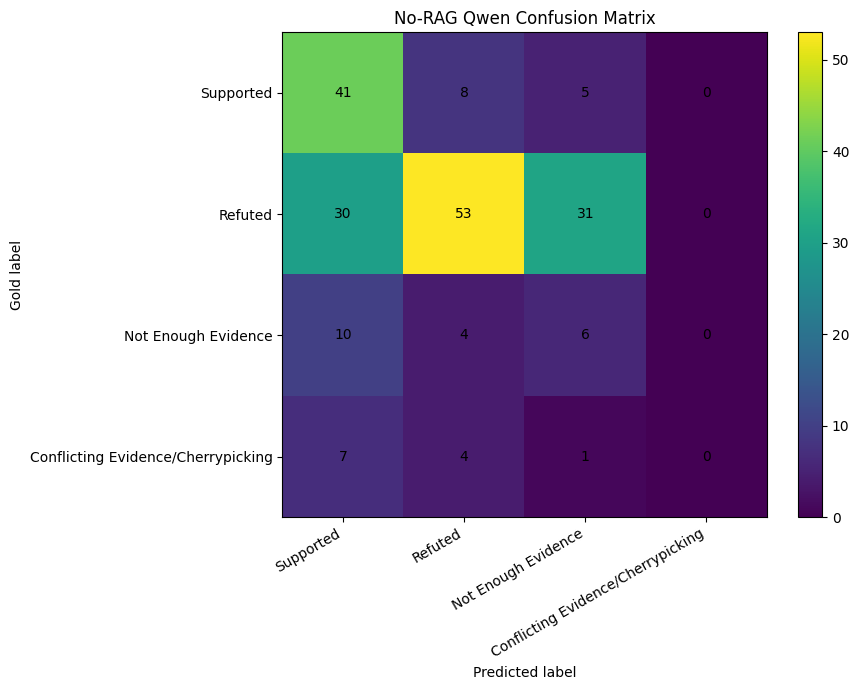

In [7]:
def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(9, 7))

    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Gold label")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))

    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, LABELS, title="No-RAG Qwen Confusion Matrix")

In [8]:
accuracy = accuracy_score(y_true, y_pred)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    target_names=LABELS,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T

print(f"Accuracy: {accuracy:.4f}")

report_df

Accuracy: 0.5000


,precision,recall,f1-score,support
Supported,0.465909,0.759259,0.577465,54.0
Refuted,0.768116,0.464912,0.579235,114.0
Not Enough Evidence,0.139535,0.300000,0.190476,20.0
Conflicting Evidence/Cherrypicking,0.000000,0.000000,0.000000,12.0
accuracy,0.500000,0.500000,0.500000,0.5
macro avg,0.343390,0.381043,0.336794,200.0
weighted avg,0.577575,0.500000,0.505127,200.0


In [9]:
from transformers import pipeline

NLI_MODEL = "facebook/bart-large-mnli"

nli_pipeline = pipeline(
    "text-classification",
    model=NLI_MODEL,
    tokenizer=NLI_MODEL,
    top_k=None,
    truncation=True,
)

c:\Users\YifanWang\miniconda3\envs\FNDrag\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 515/515 [00:00<00:00, 4023.49it/s]


In [10]:
def normalize_nli_label(label: str) -> str:
    label = label.lower()

    if "entail" in label:
        return "entailment"
    if "contrad" in label:
        return "contradiction"
    if "neutral" in label:
        return "neutral"

    return label


def run_nli(premise: str, hypothesis: str) -> dict:
    premise = str(premise)
    hypothesis = str(hypothesis)

    output = nli_pipeline({
        "text": premise,
        "text_pair": hypothesis,
    })
    if len(output) > 0 and isinstance(output[0], list):
        scores = output[0]
    else:
        scores = output

    score_dict = {
        normalize_nli_label(item["label"]): item["score"]
        for item in scores
    }

    predicted_relation = max(score_dict, key=score_dict.get)

    return {
        "nli_relation": predicted_relation,
        "nli_entailment_score": score_dict.get("entailment", 0.0),
        "nli_contradiction_score": score_dict.get("contradiction", 0.0),
        "nli_neutral_score": score_dict.get("neutral", 0.0),
    }

In [11]:
EXPECTED_NLI_RELATION = {
    "Supported": "entailment",
    "Refuted": "contradiction",
    "Not Enough Evidence": "neutral",
    "Conflicting Evidence/Cherrypicking": None,
}

In [12]:
sample_df = eval_df.head(20).copy()

nli_results = []

for _, row in sample_df.iterrows():
    result = run_nli(
        premise=row["reason"],
        hypothesis=row["claim"],
    )
    nli_results.append(result)

nli_sample_df = pd.concat(
    [
        sample_df.reset_index(drop=True),
        pd.DataFrame(nli_results),
    ],
    axis=1,
)

nli_sample_df["expected_nli_relation"] = nli_sample_df["predicted_label"].map(EXPECTED_NLI_RELATION)

nli_sample_df["reason_label_consistent"] = (
    nli_sample_df["nli_relation"] == nli_sample_df["expected_nli_relation"]
)

nli_sample_df[[
    "claim_id",
    "claim",
    "predicted_label",
    "reason",
    "nli_relation",
    "expected_nli_relation",
    "reason_label_consistent",
]]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,claim_id,claim,predicted_label,reason,nli_relation,expected_nli_relation,reason_label_consistent
0,1,Donald Trump delivered the largest tax cuts in...,Refuted,The evidence consistently shows that President...,contradiction,contradiction,True
1,6,35% of revenue goes to states. (In Nigeria),Not Enough Evidence,The provided evidence does not specifically ad...,entailment,neutral,False
2,21,There is a ‘global average’ for the number of ...,Supported,Evidence 4 directly states that there are 278 ...,entailment,entailment,True
3,50,South Africans drink more per person than anyw...,Supported,The evidence consistently indicates that South...,entailment,entailment,True
4,60,Democrats recited the US Pledge of Allegiance ...,Supported,Evidence 1 directly supports the claim by repo...,entailment,entailment,True
5,62,Israel has developed super-quick saliva test f...,Supported,"The evidence from multiple sources, including ...",entailment,entailment,True
6,75,Drinking vodka protects an individual against ...,Refuted,All the provided evidence clearly states that ...,contradiction,contradiction,True
7,79,"In 2016, 33 million Americans voted by mail.",Supported,Evidence 1 and Evidence 4 directly support the...,entailment,entailment,True
8,80,"In Michigan, US one of the three key states th...",Supported,The evidence consistently shows that Donald Tr...,neutral,entailment,False
9,84,Nigeria is the largest producer of rice in Afr...,Supported,The evidence consistently supports Nigeria as ...,neutral,entailment,False
